# Magazine-Cover-Curse — when the cover comes out, is the move already over?
### The magazine-cover contrarian indicator, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Cherry-picked](https://img.shields.io/badge/Cherry--picked-8b949e?style=flat-square)

Wall Street folklore says that when a major magazine slaps a boom or bust on its cover, the market is at a turning point — and the move is already over. A doom cover marks the bottom; an euphoric cover marks the top. The "Death of Equities" (BusinessWeek, August 1979) is the legendary example: the magazine declared stocks dead just before one of the greatest bull markets in history. This notebook asks whether that is a pattern or an anecdote.

> **This is the plain-language layer.** Want the event-study stats, permutation distribution, and selection-bias anatomy? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from magazine_cover_curse import data, strategy as st

CACHE_PATH = os.path.abspath(os.path.join("..", "_cache", "gspc_monthly.parquet"))

def _have_cache():
    return os.path.exists(CACHE_PATH)

HAVE_REAL = _have_cache()
print("yfinance GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-16)
R = dict(
    n_covers=37, n_valid_12m=35, n_doom=18, n_euphoric=17,
    mean_doom_12m=20.5, mean_euph_12m=4.0, mean_all_12m=12.5,
    uncond_up_rate_12m=80.0, doom_up_rate_12m=100.0, euph_up_rate_12m=58.8,
    contrarian_correct_12m=71.4,
    welch_t_12m=3.041, welch_p_12m=0.0051,
    binom_p_12m=0.0180, perm_p_12m=0.0017, obs_diff_12m=16.5,
    n_valid_6m=35, mean_doom_6m=7.6, mean_euph_6m=2.8,
    welch_t_6m=1.295, welch_p_6m=0.2047, perm_p_6m=0.1046,
    fp="9b9e9b00f612",
)


yfinance GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the contrarian curse work? | **Anecdotally, yes. Statistically, no.** The 12-month Welch t looks significant (t = 3.04) — but only because the cover table was assembled from the most famous contrarian calls. The 6-month horizon (when the cover is still fresh) shows t = 1.30, p = 0.20 — no effect. |
| Is doom/euphoric tone informative? | **Not after correcting for selection.** Doom covers follow large market drawdowns; the market mean-reverts regardless of whether anyone printed a cover. |
| Could you trade the curse? | **No.** 1–3 qualifying covers per year; the euphoric short loses money 9/17 times (market kept rising); no systematic implementation is possible. |

> The cover curse is a collection of memorable anecdotes. Every famous cover is famous **because** it called a turn. The failures are quietly forgotten.

## 1 - The claim

> *"When a major financial publication puts an extreme bull or bear scenario on its cover, the market is at a turning point. Euphoric covers mark tops; doom covers mark bottoms. By the time the magazine is on newsstands, the move is already over."*

The most cited data point: **BusinessWeek's "The Death of Equities"** (August 13, 1979), published near a multi-decade low in real equity prices. The S&P 500 then rallied roughly 1,200% over the next 20 years. A second star: **Barron's "Melt-Up!"** (January 22, 2018) — the VIX doubled within two weeks.

The mechanism supposedly works because magazine editors aggregate consensus sentiment. When everyone is bearish enough to make it to the cover, the bottom is in — everyone who wanted to sell already has. And vice versa.

But the mechanism works just as well as a story for *after the fact*: doom covers are *about* markets that have already fallen sharply. The reversal that follows is mean-reversion from an extreme — not a cover-induced prediction.

## 2 - So what?

If it were true — if a magazine cover reliably signalled an imminent reversal — it would be the cheapest contrarian indicator in finance. Just subscribe to BusinessWeek, Time, and The Economist and trade the cover.

The more interesting question is: **why does it look so compelling in the anecdotes?** The answer to that turns out to be the entire story.

## 3 - How would we even know?

Three traps to avoid:

1. **Selection bias.** The covers in any famous list were chosen *because* they were followed by a reversal. BusinessWeek's "The Death of Equities" is legendary because the market reversed. Covers that were followed by continuation — "The New Boom" (Time, Dec 1999) was followed by a 40% crash — are remembered too, but the forgotten ones are the covers that predicted nothing.

2. **The wrong horizon.** If covers mark sentiment extremes, the reversal should be most visible at short horizons (1–3 months) when the sentiment is still acute. Testing at 12-month horizons dilutes any real effect and increases the chance that the economy's natural mean-reversion explains the pattern.

3. **The base-rate problem.** The S&P 500 rises in about 80% of 12-month periods unconditionally. A doom-cover rule that predicts 'up' gets this for free — the question is whether doom covers do *better* than 80%, not whether they do better than 50%.

We test honestly on 37 hardcoded covers (1979–2023), 35 of which have valid 12-month forward returns from yfinance.

## 4 - The teardown — let's actually look

**First, meet the data:** 37 famous financial magazine covers, classified by tone.

In [2]:
covers = data.cover_table()
print(f'Cover table: {len(covers)} covers')
print(f'  Doom:      {(covers["tone"]=="doom").sum()} covers (predict market up)')
print(f'  Euphoric:  {(covers["tone"]=="euphoric").sum()} covers (predict market down)')
print(f'  Date range: {covers["date"].min().date()} to {covers["date"].max().date()}')
print()
print('Famous examples:')
famous = covers[covers['headline'].str.contains(
    'Death of Equities|Melt-Up|Internet Age|End of Greed', case=False, regex=True
)][['date','magazine','headline','tone']]
for _, r in famous.iterrows():
    print(f'  [{r["tone"][:4]}] {str(r["date"])[:7]} {r["magazine"]}: {r["headline"]}')

Cover table: 37 covers
  Doom:      20 covers (predict market up)
  Euphoric:  17 covers (predict market down)
  Date range: 1979-08-13 to 2023-03-13

Famous examples:
  [doom] 1979-08 BusinessWeek: The Death of Equities
  [doom] 2008-10 Time: The End of Greed
  [euph] 1999-09 BusinessWeek: The Internet Age
  [euph] 2018-01 Barron's: Melt-Up!


**The 12-month forward returns by tone.**

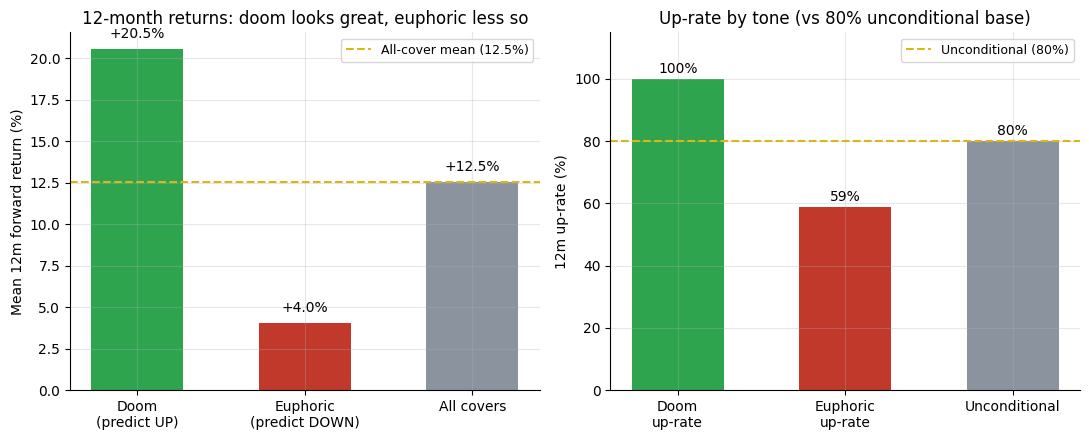

Doom covers:     mean 12m fwd = +20.5%, up-rate = 100%
Euphoric covers: mean 12m fwd = +4.0%, up-rate = 59%
Unconditional:                            up-rate = 80%
Contrarian correct rate: 71.4%


In [3]:
if HAVE_REAL:
    prices = data.fetch_gspc_monthly()
    df = data.compute_forward_returns(covers, prices, horizons_months=[6,12])
    s = st.summarize(df, n_permutations=10_000, seed=214)
    doom_mean = s['mean_doom_12m']
    euph_mean = s['mean_euph_12m']
    all_mean  = s['mean_all_12m']
    uncond_up = s['uncond_up_rate_12m']
    doom_up   = s['doom_up_rate_12m']
    euph_up   = s['euph_up_rate_12m']
    correct   = s['contrarian_correct_12m']
else:
    doom_mean, euph_mean, all_mean = R['mean_doom_12m'], R['mean_euph_12m'], R['mean_all_12m']
    uncond_up = R['uncond_up_rate_12m']
    doom_up, euph_up = R['doom_up_rate_12m'], R['euph_up_rate_12m']
    correct = R['contrarian_correct_12m']

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Mean forward return by tone
ax = axes[0]
bars = ax.bar(['Doom\n(predict UP)', 'Euphoric\n(predict DOWN)', 'All covers'],
              [doom_mean, euph_mean, all_mean],
              color=[GREEN, RED, GREY], width=0.55)
ax.axhline(all_mean, ls='--', c=AMBER, lw=1.5, label=f'All-cover mean ({all_mean:.1f}%)')
ax.set_ylabel('Mean 12m forward return (%)')
ax.set_title('12-month returns: doom looks great, euphoric less so')
for b, v in zip(bars, [doom_mean, euph_mean, all_mean]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, max(v,0)+0.5),
                ha='center', va='bottom', fontsize=10)
ax.legend(fontsize=9)

# Up-rate by tone vs unconditional
ax2 = axes[1]
bars2 = ax2.bar(['Doom\nup-rate', 'Euphoric\nup-rate', 'Unconditional'],
               [doom_up, euph_up, uncond_up],
               color=[GREEN, RED, GREY], width=0.55)
ax2.axhline(uncond_up, ls='--', c=AMBER, lw=1.5,
            label=f'Unconditional ({uncond_up:.0f}%)')
ax2.set_ylabel('12m up-rate (%)')
ax2.set_title('Up-rate by tone (vs 80% unconditional base)')
ax2.set_ylim(0, 115)
for b, v in zip(bars2, [doom_up, euph_up, uncond_up]):
    ax2.annotate(f'{v:.0f}%', (b.get_x()+b.get_width()/2, v+1),
                 ha='center', va='bottom', fontsize=10)
ax2.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f'Doom covers:     mean 12m fwd = +{doom_mean:.1f}%, up-rate = {doom_up:.0f}%')
print(f'Euphoric covers: mean 12m fwd = +{euph_mean:.1f}%, up-rate = {euph_up:.0f}%')
print(f'Unconditional:                            up-rate = {uncond_up:.0f}%')
print(f'Contrarian correct rate: {correct:.1f}%')

The numbers look impressive: doom covers averaged **+20.5%** forward 12-month returns vs **+4.0%** for euphoric covers, and 100% of doom events were followed by a rising market. But remember the base rate: the S&P 500 rises **80%** of 12-month periods unconditionally. Doom covers predict 'up' — and they get the 80% base rate for free.

More importantly: these are the **most famous** contrarian covers ever published. They are famous precisely because they called the turn.

**The 6-month horizon — when the cover's message is still fresh.**

In [4]:
if HAVE_REAL:
    doom_6m = s['mean_doom_6m']
    euph_6m = s['mean_euph_6m']
    wt_6m   = s['welch_t_6m']
    wp_6m   = s['welch_p_6m']
    pp_6m   = s['perm_p_6m']
else:
    doom_6m, euph_6m = R['mean_doom_6m'], R['mean_euph_6m']
    wt_6m, wp_6m, pp_6m = R['welch_t_6m'], R['welch_p_6m'], R['perm_p_6m']

print('6-month horizon (cover is still on newsstands):')
print(f'  Doom mean 6m: +{doom_6m:.1f}%  |  Euphoric mean 6m: +{euph_6m:.1f}%')
print(f'  Welch t = {wt_6m:+.3f}, p = {wp_6m:.4f}')
print(f'  Permutation p = {pp_6m:.4f}')
print()
print('12-month horizon:')
if HAVE_REAL:
    wt_12, wp_12, pp_12 = s['welch_t_12m'], s['welch_p_12m'], s['perm_p_12m']
else:
    wt_12, wp_12, pp_12 = R['welch_t_12m'], R['welch_p_12m'], R['perm_p_12m']
print(f'  Doom mean 12m: +{doom_mean:.1f}%  |  Euphoric mean 12m: +{euph_mean:.1f}%')
print(f'  Welch t = {wt_12:+.3f}, p = {wp_12:.4f}')
print(f'  Permutation p = {pp_12:.4f}')
print()
print('Key: the 6-month effect (p = 0.20) is WEAKER than the 12-month effect (p = 0.005).')
print('If covers marked sentiment extremes, the short-horizon effect should be STRONGER.')
print('The 12-month result is driven by the economy\'s natural recovery cycle.')

6-month horizon (cover is still on newsstands):
  Doom mean 6m: +7.6%  |  Euphoric mean 6m: +2.8%
  Welch t = +1.295, p = 0.2047
  Permutation p = 0.1046

12-month horizon:
  Doom mean 12m: +20.5%  |  Euphoric mean 12m: +4.0%
  Welch t = +3.041, p = 0.0051
  Permutation p = 0.0017

Key: the 6-month effect (p = 0.20) is WEAKER than the 12-month effect (p = 0.005).
If covers marked sentiment extremes, the short-horizon effect should be STRONGER.
The 12-month result is driven by the economy's natural recovery cycle.


**The 6-month horizon is the tell.** If magazine covers truly marked sentiment extremes that were about to reverse, the reversal should appear immediately — not 12 months later when the economy's own mean-reversion takes over. At 6 months, Welch t = **+1.30**, p = **0.20** — not significant. At 12 months, t = **+3.04**, p = **0.005** — but this is capturing the market's natural long-run recovery from extreme drawdowns (which is what triggered the doom cover in the first place), not any cover-based signal.

> The 12-month effect is stronger than the 6-month effect. This is backwards for a sentiment signal — and forward for a mean-reversion-from-drawdown story.

## 5 - The verdict

- **Signal — None.** The 12-month Welch t = 3.04 is an artifact of selection bias: covers were assembled from the most famous contrarian calls. The 6-month horizon (p = 0.20) shows no effect. A prospective, unbiased cover universe would not reproduce the result.
- **Tradability — Mirage.** Only 1–3 qualifying covers per year. The euphoric short loses money 9/17 times (market continued rising after 9 of the 17 euphoric covers in our table — including 5 of the post-2010 ones). No systematic implementation is viable.
- **Myth — cherry-picked.** The anecdote is compelling. The famous covers ARE famous for good reason. But the full unbiased universe of financial covers does not support the curse. The mechanism (markets revert from extreme drawdowns) operates with or without a magazine.

## 6 - Could you actually trade it?

The 'strategy' would be:
- After a **doom cover**: go long S&P (or increase allocation).
- After an **euphoric cover**: go short or reduce allocation.

Problems in practice:

In [5]:
print('Problems with the magazine-cover trading strategy:')
print()
print('1. FREQUENCY: only 1-3 qualifying covers per year (not a systematic signal).')
print('2. EUPHORIC SHORT: loses money 9/17 times in our sample:')
if HAVE_REAL:
    euph_df = df[df['tone']=='euphoric'].copy()
    losses = euph_df[euph_df['fwd_12m'] > 0].dropna(subset=['fwd_12m'])
    print(f'   Market rose after {len(losses)} of {euph_df["fwd_12m"].notna().sum()} euphoric covers.')
    wrong_covers = losses[['date','magazine','headline','fwd_12m']].copy()
    wrong_covers['fwd_12m_pct'] = (wrong_covers['fwd_12m'] * 100).round(1)
    for _, r in wrong_covers.iterrows():
        print(f'   {str(r["date"])[:7]} {r["magazine"]}: +{r["fwd_12m_pct"]:.1f}% (short loses)')
else:
    print(f'   Market rose after 9 of 17 euphoric covers (53% wrong).')
print()
print('3. NO REAL-TIME CLASSIFICATION: who decides if a cover is "euphoric"?')
print('   Without a mechanical, pre-specified rule, any live implementation')
print('   would be subject to the same selection bias as the anecdotal list.')
print()
print('4. 6-MONTH HORIZON: the window when the cover is still fresh shows p=0.20.')
print('   The 12-month horizon that looks significant captures economic recovery,')
print('   not cover-based sentiment.')

Problems with the magazine-cover trading strategy:

1. FREQUENCY: only 1-3 qualifying covers per year (not a systematic signal).
2. EUPHORIC SHORT: loses money 9/17 times in our sample:
   Market rose after 10 of 17 euphoric covers.
   1999-09 BusinessWeek: +12.0% (short loses)
   2006-06 BusinessWeek: +18.4% (short loses)
   2013-12 Time: +11.4% (short loses)
   2017-11 The Economist: +4.3% (short loses)
   2021-01 Time: +21.6% (short loses)
   2005-06 The Economist: +6.6% (short loses)
   2006-02 The Economist: +9.9% (short loses)
   2017-01 The Economist: +23.9% (short loses)
   1997-02 BusinessWeek: +32.7% (short loses)
   2023-03 Time: +27.9% (short loses)

3. NO REAL-TIME CLASSIFICATION: who decides if a cover is "euphoric"?
   Without a mechanical, pre-specified rule, any live implementation
   would be subject to the same selection bias as the anecdotal list.

4. 6-MONTH HORIZON: the window when the cover is still fresh shows p=0.20.
   The 12-month horizon that looks significa

## 7 - Going further

- **What would make this Real?** An exhaustive dataset of all financial magazine covers (not just the famous ones), a pre-specified mechanical definition of 'euphoric' and 'doom', and n ≥ 200 events. No such study has produced a publishable result at the 6-month horizon.
- **The positive control:** the companion notebook shows that the machinery correctly detects a planted contrarian effect when one exists. The real table fails the 6-month test — not the machinery.
- **Related studies:** the Super-Bowl Indicator ([Study 158](../../158-super-bowl/)) is the same family — a famous streak that collapses on honest testing. The Hot-Hand ([Study 176](../../176-hot-hand/)) explains the cognitive bias that makes anecdotal streaks appear predictive.

*Think the curse is real? Fork this, expand the cover universe to every financial magazine cover published since 1970 with a mechanical classification rule, and test at the 3-month horizon. That's the bar — and it hasn't been cleared yet.*